# Matrix-Making Notebook

The purpose of this notebook is to create matrix-like figures that summarize accuracy of the model across various experiments run in climate_experiments.ipynb.

### Imports and File Stitching

In [4]:
# General Imports
import pandas as pd
import numpy as np
import os
import sys
import glob

# Combinations
from itertools import combinations

# Plotting
import matplotlib.pyplot as plt

# ----File Stitching----
# If in climate_experiments folder, cd back to MamalakisResearch folder
if os.path.basename(os.getcwd()) == "climate_experiments":
    os.chdir('..')
# If a file is in /data_prep_viz/prep/, access it by telling the system to look at that path as well as current path
sys.path.append(os.path.join(os.getcwd(), '..', 'data_prep_viz/prep'))

### Read Files

In [5]:
# Read csv files
summary_1 = pd.read_csv("climate_experiments/experiment_summary_ck_1.csv")
summary_2 = pd.read_csv("climate_experiments/experiment_summary_ck_2.csv")
# ^ Make into a for loop eventually
summaries = [summary_1, summary_2]

In [6]:
# Read all csv files in climate_experiments folder
path = os.getcwd() + '/climate_experiments/'
csvs = glob.glob(os.path.join(path, "*.csv"))
summaries = []
for csv in csvs:
    df = pd.read_csv(csv)
    summaries.append(df)

### Calculations

In [7]:
# Calculate mean and standard deviation of accuracy between runs of the same experiment
def get_mean_std(summaries):
    # Make a df to hold: 
    # a) metadata
    acc_df = pd.DataFrame(columns=['scenario','early', 'late'])
    acc_df['scenario'] = summaries[0]['scenario']
    acc_df['early'] = summaries[0]['early']
    acc_df['late'] = summaries[0]['late']
    
    # b) accuracies
    for i in range(len(csvs)-1):
        acc_df[f"acc_{i}"] = summaries[i]['mean_pred']  ## Change to accuracy
    
    # c) mean and std
    acc_cols = [col for col in acc_df.columns if col.startswith('acc_')]
    acc_df['mean'] = acc_df[acc_cols].mean(axis=1)
    acc_df['std'] = acc_df[acc_cols].std(axis=1)
    
    return acc_df

In [8]:
mean_std = get_mean_std(summaries)
mean_std.head()

,scenario,early,late,acc_0,acc_1,mean,std
0,ssp119,2015,2025,0.488683,0.590495,0.539589,0.071992
1,ssp119,2015,2035,0.590137,0.511218,0.550678,0.055804
2,ssp119,2015,2045,0.487564,0.563199,0.525382,0.053482
3,ssp119,2015,2055,0.738778,0.470238,0.604508,0.189887
4,ssp119,2015,2065,0.459767,0.489292,0.474529,0.020878


### Making a Matrix

In [9]:
# Make a copy
mean_std = mean_std.copy()
# Create the label pairings by changing scenario-early-late to a single, concatenated index
mean_std['label'] = mean_std['scenario'] + '_' + mean_std['early'].astype(str) + '_' + mean_std['late'].astype(str)
mean_std = mean_std.drop(columns=['scenario', 'early', 'late'])
# Drop the acc columns
mean_std = mean_std.drop(columns=[col for col in mean_std.columns if col.startswith('acc_')])
mean_std.set_index('label', inplace=True)
mean_std_119 = mean_std.filter(like='119', axis=0)
mean_std_126 = mean_std.filter(like='126', axis=0)
mean_std_119.head()

,mean,std
label,,
ssp119_2015_2025,0.539589,0.071992
ssp119_2015_2035,0.550678,0.055804
ssp119_2015_2045,0.525382,0.053482
ssp119_2015_2055,0.604508,0.189887
ssp119_2015_2065,0.474529,0.020878


Website I'm using https://stackoverflow.com/questions/66823573/how-to-turn-pandas-series-into-a-matrix

In [12]:
# Expand to a comparison matrix - unique pairs only
index = [f"{a} vs {b}" for a, b in combinations(mean_std_119.index, 2)]
values = [a - b for a, b in combinations(mean_std_119['mean'], 2)]

TypeError: Invalid shape (27,) for image data

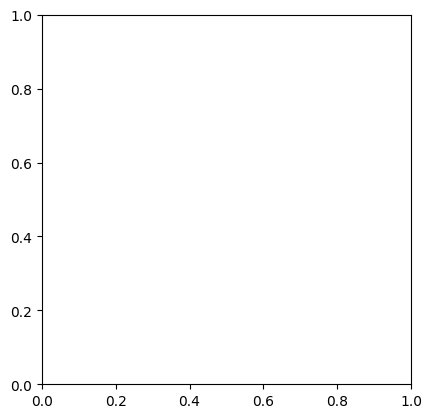

In [11]:
# Function to plot with colors and labels
def matshow_plot(df):
    labels = index
    data = df['mean']
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(data, interpolation='nearest')
    fig.colorbar(cax)

    ax.set_xticklabels(['']+labels)
    ax.set_yticklabels(['']+labels)

    plt.show()

matshow_plot(mean_std_119)


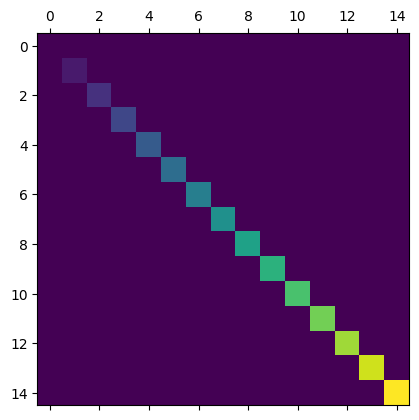

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# a 2D array with linearly increasing values on the diagonal
a = np.diag(range(15))

plt.matshow(a)

plt.show()

In [ ]:
import torch
print(torch.cuda.is_available())      # True
print(torch.cuda.get_device_name(0))  # NVIDIA T1200 Laptop GPU
print(torch.version.cuda)             # 13.0

True
NVIDIA T1200 Laptop GPU
12.8
